In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load raw metadata files
proj_df = pd.read_csv('indiana_projections.csv')
reports_df = pd.read_csv('indiana_reports.csv')

# 2. Merge on unique patient/study ID
df = pd.merge(proj_df, reports_df, on='uid')

# 3. Filter strictly for Frontal views (PA/AP)
df_frontal = df[df['projection'] == 'Frontal'].copy()

# 4. Enforce single-label rule for target classes
def get_single_label(tags):
    tags = str(tags).lower()
    has_cardiomegaly = "cardiomegaly" in tags
    has_effusion = "pleural effusion" in tags or "effusion" in tags
    has_normal = "normal" in tags
    
    # Exclude cases with multiple overlapping findings or non-target findings
    if sum([has_cardiomegaly, has_effusion, has_normal]) > 1:
        return "Exclude"
    elif has_cardiomegaly:
        return "Cardiomegaly"
    elif has_effusion:
        return "Pleural Effusion"
    elif has_normal:
        return "Normal"
    else:
        return "Exclude"

df_frontal['y_label'] = df_frontal['MeSH'].apply(get_single_label)
df_filtered = df_frontal[df_frontal['y_label'] != 'Exclude'].copy()

# 5. Create a balanced dataset of exactly 300 images (100 per class)
df_subset = df_filtered.groupby('y_label').sample(n=100, random_state=42)

# 6. Set Findings/Impression as ground-truth report
df_subset['y_report'] = df_subset['findings'].fillna(df_subset['impression'])
df_final = df_subset[['filename', 'y_label', 'y_report']].rename(columns={'filename': 'image'})

# 7. Create fixed split: 70% Train (210), 10% Val (30), 20% Test (60)
train_df, temp_df = train_test_split(df_final, test_size=0.30, stratify=df_final['y_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.66, stratify=temp_df['y_label'], random_state=42)

# 8. Save fixed splits to CSV for reproducibility
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print(f"Dataset Split Complete -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Dataset Split Complete -> Train: 210 | Val: 30 | Test: 60


In [3]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class XRayDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.label_map = {"Normal": 0, "Cardiomegaly": 1, "Pleural Effusion": 2}

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.data_frame.iloc[idx]['image'])
        image = Image.open(img_name).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        label_str = self.data_frame.iloc[idx]['y_label']
        label = self.label_map[label_str]
        
        return image, label

# Data Augmentation & Normalization
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = XRayDataset('train_split.csv', 'images/', train_transform)
val_dataset   = XRayDataset('val_split.csv', 'images/', eval_transform)
test_dataset  = XRayDataset('test_split.csv', 'images/', eval_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. ResNet-18 Setup ---
resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 3)
resnet_model = resnet_model.to(device)
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=1e-4)

# --- 2. Vision Transformer Setup ---
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
for param in vit_model.parameters():
    param.requires_grad = False  # Freeze backbone

num_ftrs_vit = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(num_ftrs_vit, 3)
vit_model = vit_model.to(device)
optimizer_vit = optim.AdamW(vit_model.heads.head.parameters(), lr=1e-3, weight_decay=0.01)

In [5]:
criterion = nn.CrossEntropyLoss()

def train_and_evaluate(model, optimizer, train_loader, val_loader, test_loader, epochs=10):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        val_acc = 100 * val_correct / val_total
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")
        
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
    test_acc = 100 * test_correct / test_total
    return test_acc

print("--- Training ResNet-18 ---")
resnet_acc = train_and_evaluate(resnet_model, optimizer_resnet, train_loader, val_loader, test_loader, epochs=10)

print("\n--- Training Vision Transformer ---")
vit_acc = train_and_evaluate(vit_model, optimizer_vit, train_loader, val_loader, test_loader, epochs=10)

print("=" * 50)
print(f"RESULTS -> ResNet-18 Test Accuracy: {resnet_acc:.2f}% | ViT Test Accuracy: {vit_acc:.2f}%")
print("=" * 50)

--- Training ResNet-18 ---
Epoch 1/10 | Train Loss: 1.0117 | Val Acc: 36.67%
Epoch 2/10 | Train Loss: 0.7740 | Val Acc: 36.67%
Epoch 3/10 | Train Loss: 0.6129 | Val Acc: 40.00%
Epoch 4/10 | Train Loss: 0.4447 | Val Acc: 56.67%
Epoch 5/10 | Train Loss: 0.4703 | Val Acc: 63.33%
Epoch 6/10 | Train Loss: 0.4287 | Val Acc: 73.33%
Epoch 7/10 | Train Loss: 0.2890 | Val Acc: 70.00%
Epoch 8/10 | Train Loss: 0.3677 | Val Acc: 66.67%
Epoch 9/10 | Train Loss: 0.2939 | Val Acc: 60.00%
Epoch 10/10 | Train Loss: 0.3249 | Val Acc: 70.00%

--- Training Vision Transformer ---
Epoch 1/10 | Train Loss: 1.0857 | Val Acc: 60.00%
Epoch 2/10 | Train Loss: 0.9730 | Val Acc: 60.00%
Epoch 3/10 | Train Loss: 0.8625 | Val Acc: 60.00%
Epoch 4/10 | Train Loss: 0.7560 | Val Acc: 56.67%
Epoch 5/10 | Train Loss: 0.7664 | Val Acc: 60.00%
Epoch 6/10 | Train Loss: 0.7079 | Val Acc: 60.00%
Epoch 7/10 | Train Loss: 0.7305 | Val Acc: 60.00%
Epoch 8/10 | Train Loss: 0.6851 | Val Acc: 60.00%
Epoch 9/10 | Train Loss: 0.7178 | V

In [6]:
import os
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Load Pretrained Medical BLIP Model
model_id = "nathansutton/generate-cxr"
processor = BlipProcessor.from_pretrained(model_id)
report_model = BlipForConditionalGeneration.from_pretrained(model_id).to(device)
report_model.eval()

def generate_report_from_image(image_path, model, processor, device):
    """
    Strict Task B Implementation:
    Takes ONLY the X-ray image as input to generate the report.
    No classifier guidance or prompt engineering used.
    """
    raw_image = Image.open(image_path).convert('RGB')
    inputs = processor(images=raw_image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        out = model.generate(
            **inputs, 
            max_new_tokens=120, 
            num_beams=3, 
            repetition_penalty=2.0
        )
        
    return processor.decode(out[0], skip_special_tokens=True).strip()

c:\Users\User\Desktop\xray classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 616/616 [00:00<00:00, 10015.04it/s]
[transformers] The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


             FINAL DEMO: 10 UNSEEN TEST X-RAYS EVALUATION                 

--- SAMPLE #1 [153_IM-0343-1001.dcm.png] ---
1. Input Image            : 153_IM-0343-1001.dcm.png
2. Ground-Truth Label     : Pleural Effusion
3. ResNet Prediction      : Pleural Effusion
4. ViT Prediction         : Normal
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : There is a right IJ central venous catheter with tip overlying the inferior SVC. Cardiac silhouette is normal size. Normal mediastinal contour and pulmonary vasculature. There is a small right pleural effusion. Otherwise, lungs are without focal airspace disease.
7. Generated Report       : history : - year - old male with cough and fever. findings : frontal and lateral views of the chest were obtained. the heart size and cardiomediastinal contours are normal. the lungs are clear. no focal consolidation, pleural effusion, or pneumothorax. impression : no acute cardiopulmonary process.
------------------------------

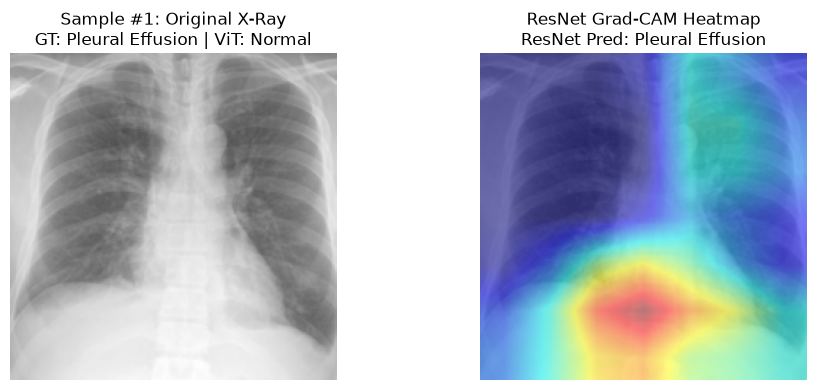


--- SAMPLE #2 [3870_IM-1963-4001.dcm.png] ---
1. Input Image            : 3870_IM-1963-4001.dcm.png
2. Ground-Truth Label     : Pleural Effusion
3. ResNet Prediction      : Pleural Effusion
4. ViT Prediction         : Pleural Effusion
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : 1. Worsening bilateral lower lobe opacities which are most XXXX due to enlarging bilateral pleural effusions. Superimposed lower lobe airspace abnormalities are possible. Negative for pneumothorax. 2. Normal heart size and pulmonary vascularity. 3. Left upper extremity PICC terminates in the lower SVC. .
7. Generated Report       : indication : year old woman with pleural effusion s / p thoracentesis / /? ptx. technique - chest pa and lateral. findings : there has been interval decrease in size of the right pleural effusion, now small to moderate. no left pleural effusion. no focal consolidation or pneumothorax identified. the size of the cardiomediastinal silhouette is within

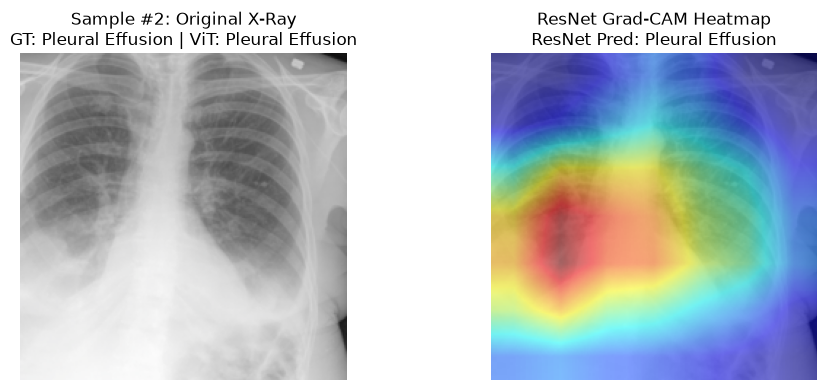


--- SAMPLE #3 [3451_IM-1674-1001.dcm.png] ---
1. Input Image            : 3451_IM-1674-1001.dcm.png
2. Ground-Truth Label     : Pleural Effusion
3. ResNet Prediction      : Pleural Effusion
4. ViT Prediction         : Pleural Effusion
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : The heart is normal in size. The mediastinum is Stable. Calcified AP XXXX lymph XXXX are seen. A small right-sided pleural effusion versus thickening. Right inferior rib deformities.
7. Generated Report       : history : - year - old female with cough. findings : frontal and lateral views of the chest were obtained. the heart size and cardiomediastinal contours are normal. the lungs are clear. no focal consolidation, pleural effusion, or pneumothorax. impression : no acute cardiopulmonary process.
---------------------------------------------------------------------------


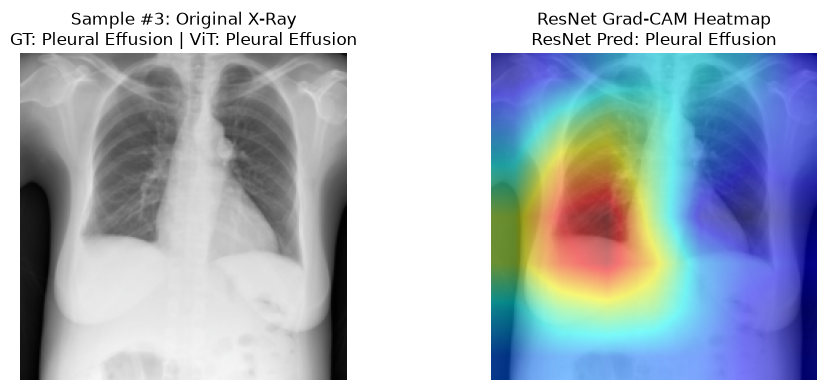


--- SAMPLE #4 [2999_IM-1383-0001-0001.dcm.png] ---
1. Input Image            : 2999_IM-1383-0001-0001.dcm.png
2. Ground-Truth Label     : Pleural Effusion
3. ResNet Prediction      : Pleural Effusion
4. ViT Prediction         : Normal
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : The cardiac silhouette is at the upper limits of normal for size. Patchy opacities are demonstrated in the left lung base. No focal pulmonary consolidation. No pneumothorax. Minimal degenerative changes of the thoracic spine.
7. Generated Report       : indication : history - m with cough, fever / / eval for pna. technique - chest pa and lateral. findings : there is no focal consolidation, pleural effusion or pneumothorax. the cardiomediastinal silhouette is normal. the imaged upper abdomen is unremarkable. the bones are intact. impression : no acute cardiopulmonary process.
---------------------------------------------------------------------------


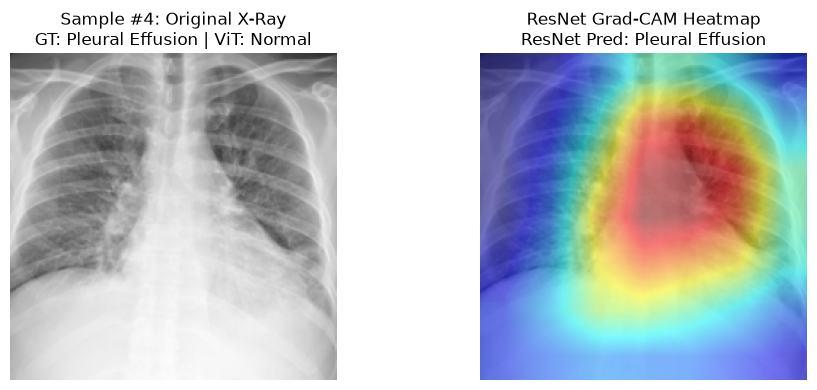


--- SAMPLE #5 [612_IM-2199-1001.dcm.png] ---
1. Input Image            : 612_IM-2199-1001.dcm.png
2. Ground-Truth Label     : Cardiomegaly
3. ResNet Prediction      : Pleural Effusion
4. ViT Prediction         : Cardiomegaly
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : Interval performance of anterior cervical spinal fusion, XXXX intact without complicating features. There is stable cardiomegaly, with persistent bibasilar opacities XXXX atelectasis and/or infiltrate. No XXXX focal consolidations, pneumothorax, or pleural effusions. The visualized osseous structures demonstrate mild multilevel degenerative disc disease of the thoracolumbar spine, without acute osseous abnormality.
7. Generated Report       : history : - year - old female with shortness of breath. findings : the heart size is within normal limits. the mediastinal and hilar contours are normal. the lungs are clear. there is no pleural effusion or pneumothorax. impression : no acute cardi

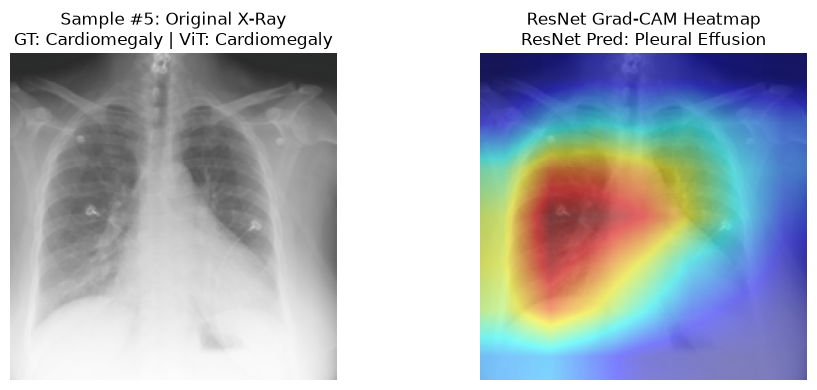


--- SAMPLE #6 [2020_IM-0668-1001.dcm.png] ---
1. Input Image            : 2020_IM-0668-1001.dcm.png
2. Ground-Truth Label     : Normal
3. ResNet Prediction      : Normal
4. ViT Prediction         : Normal
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : No focal lung consolidation. Heart size and pulmonary vascularity are within normal limits. No pneumothorax or pleural effusion. Osseous structures are grossly intact.
7. Generated Report       : indication : - year - old male with chest pain. findings : no focal consolidation, pleural effusion, pneumothorax, or pulmonary edema is detected. heart and mediastinal contours are within normal limits. impression : no radiographic evidence for acute cardiopulmonary process.
---------------------------------------------------------------------------


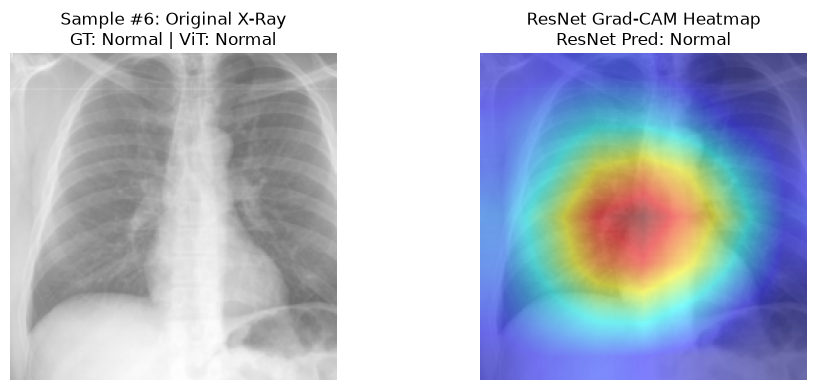


--- SAMPLE #7 [1743_IM-0489-4004.dcm.png] ---
1. Input Image            : 1743_IM-0489-4004.dcm.png
2. Ground-Truth Label     : Cardiomegaly
3. ResNet Prediction      : Cardiomegaly
4. ViT Prediction         : Cardiomegaly
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : Considering differences in technical factors XXXX stable cardiomegaly and stable mediastinal contours. No focal alveolar consolidation, no definite pleural effusion seen. Bronchovascular crowding without typical findings of pulmonary edema.
7. Generated Report       : history : - year - old female with fever. findings : single portable view of the chest. the lungs are grossly clear. cardiomediastinal silhouette is within normal limits. osseous and soft tissue structures are unremarkable. impression : no acute cardiopulmonary process.
---------------------------------------------------------------------------


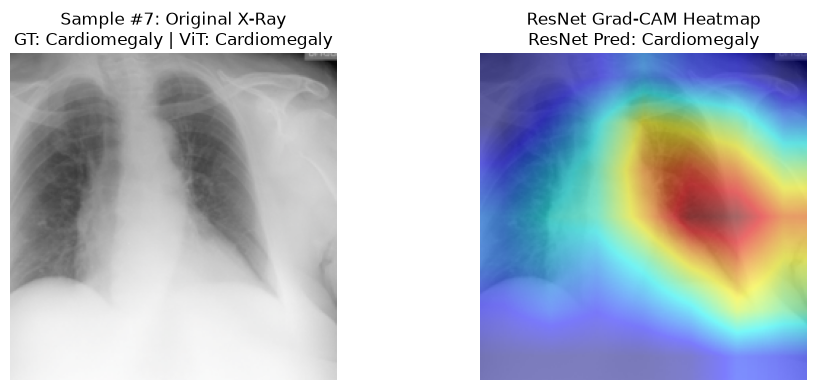


--- SAMPLE #8 [2220_IM-0824-4004.dcm.png] ---
1. Input Image            : 2220_IM-0824-4004.dcm.png
2. Ground-Truth Label     : Pleural Effusion
3. ResNet Prediction      : Pleural Effusion
4. ViT Prediction         : Normal
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : The XXXX examination consists of frontal and lateral radiographs of the chest. There low lung volumes. There is pulmonary vascular congestion and indistinctness. Bibasilar airspace disease is also present. Probable XXXX left pleural effusion. No evidence of pneumothorax. Cardiac silhouette is upper lungs are normally accentuated due to low lung volumes.
7. Generated Report       : history : - year - old male with shortness of breath. findings : single frontal view of the chest was obtained. lung volumes are low, exaggerating heart size and bronchovascular markings. cardiomediastinal contours are stable. no focal consolidation, pleural effusion, or pneumothorax. impression : low lung vol

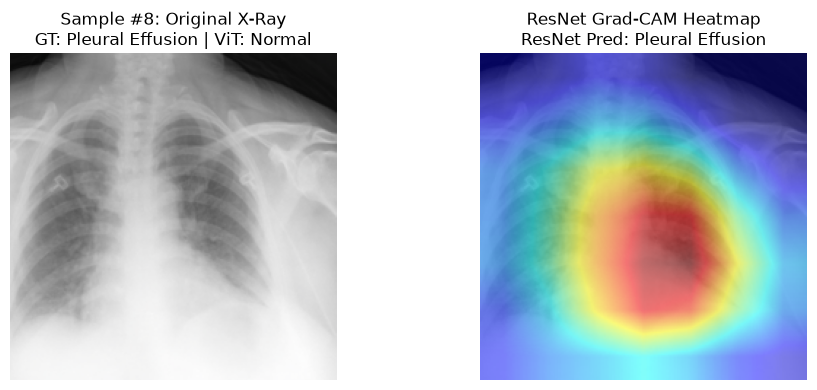


--- SAMPLE #9 [1234_IM-0157-4004.dcm.png] ---
1. Input Image            : 1234_IM-0157-4004.dcm.png
2. Ground-Truth Label     : Cardiomegaly
3. ResNet Prediction      : Cardiomegaly
4. ViT Prediction         : Cardiomegaly
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : 2 images. The cardiac silhouette is enlarged. Thoracic aortic atherosclerotic calcifications are present. There are finding status post sternotomy and CABG. XXXX atelectasis or scar is noted within the left midlung. There is blunting of the left costophrenic XXXX. No pneumothorax.
7. Generated Report       : indication : year old woman with copd exacerbation / / eval for pna. technique - chest pa and lateral. findings : cardiomediastinal contours are normal. the lungs are clear. there is no pneumothorax or pleural effusion. the osseous structures are unremarkable. impression : no acute cardiopulmonary abnormalities.
-------------------------------------------------------------------------

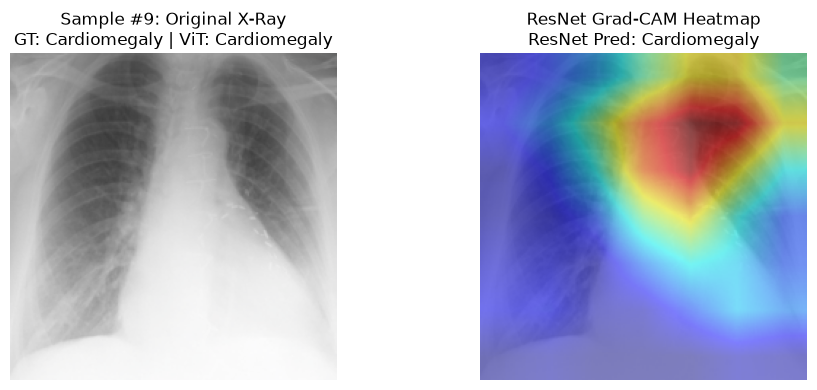


--- SAMPLE #10 [946_IM-2441-1001.dcm.png] ---
1. Input Image            : 946_IM-2441-1001.dcm.png
2. Ground-Truth Label     : Normal
3. ResNet Prediction      : Normal
4. ViT Prediction         : Normal
5. ResNet Grad-CAM        : Rendered in Plot below
6. Ground-Truth Report    : Heart size is normal. The lungs are clear. There are no focal air space consolidations. No pleural effusions or pneumothoraces. The hilar and mediastinal contours are normal. Normal pulmonary vascularity.
7. Generated Report       : indication : year old woman with cough, fever / / r / o pna. findings : cardiomediastinal contours are normal. the lungs are clear. there is no pneumothorax or pleural effusion. the osseous structures are unremarkable. impression : no acute cardiopulmonary abnormalities.
---------------------------------------------------------------------------


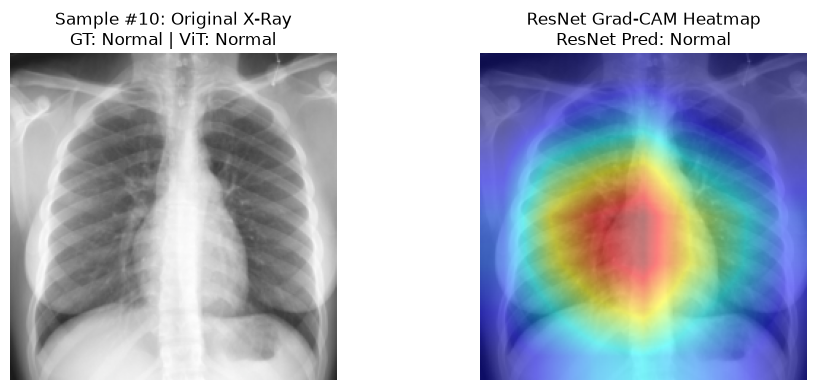

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class_names = ["Normal", "Cardiomegaly", "Pleural Effusion"]
test_df = pd.read_csv("test_split.csv")

# Initialize Grad-CAM on ResNet-18
target_layers = [resnet_model.layer4[-1]]
cam = GradCAM(model=resnet_model, target_layers=target_layers)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

print("==========================================================================")
print("             FINAL DEMO: 10 UNSEEN TEST X-RAYS EVALUATION                 ")
print("==========================================================================")

for i in range(10):
    image_filename = test_df.iloc[i]['image']
    img_path = f"images/{image_filename}"
    gt_report = test_df.iloc[i]['y_report']
    gt_label = test_df.iloc[i]['y_label']
    
    # Load tensor for classification models
    image_tensor, _ = test_dataset[i]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # 1. ResNet Prediction
    resnet_model.eval()
    with torch.no_grad():
        res_pred_idx = resnet_model(input_tensor).argmax(dim=1).item()
        res_pred_label = class_names[res_pred_idx]
        
    # 2. ViT Prediction
    vit_model.eval()
    with torch.no_grad():
        vit_pred_idx = vit_model(input_tensor).argmax(dim=1).item()
        vit_pred_label = class_names[vit_pred_idx]
        
    # 3. Direct Image-to-Text Report Generation (Task B)
    generated_report = generate_report_from_image(img_path, report_model, processor, device)
    
    # 4. Grad-CAM Overlay Generation
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    img_np = image_tensor.numpy().transpose(1, 2, 0)
    img_np = np.clip(std * img_np + mean, 0, 1)
    cam_overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    
    # Print 7 Required Deliverables in Text Summary
    print(f"\n--- SAMPLE #{i+1} [{image_filename}] ---")
    print(f"1. Input Image            : {image_filename}")
    print(f"2. Ground-Truth Label     : {gt_label}")
    print(f"3. ResNet Prediction      : {res_pred_label}")
    print(f"4. ViT Prediction         : {vit_pred_label}")
    print(f"5. ResNet Grad-CAM        : Rendered in Plot below")
    print(f"6. Ground-Truth Report    : {gt_report}")
    print(f"7. Generated Report       : {generated_report}")
    print("-" * 75)
    
    # Visual Dashboard Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].imshow(img_np)
    axes[0].set_title(f"Sample #{i+1}: Original X-Ray\nGT: {gt_label} | ViT: {vit_pred_label}")
    axes[0].axis('off')
    
    axes[1].imshow(cam_overlay)
    axes[1].set_title(f"ResNet Grad-CAM Heatmap\nResNet Pred: {res_pred_label}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()